# EDA and Four-Stage Selection (2010-July 2026)

## Objective

- Use images from **2010-2022** for four sequential continual-learning stages.
- Reserve **2023-2024** for validation.
- Reserve **2025-July 2026** for final testing.
- Compare chronological stage boundaries using both dataset size and class imbalance.
- Select a practical split for later experiments with Elastic Weight Consolidation (EWC).

## Binary target

Each image is labelled using the strongest flare in its following 24-hour window:

- **FL = 1:** M-class or X-class flare.
- **NF = 0:** A-class, B-class, C-class, or no flare.

> A, B, and C events are real flares, but they are negative samples for this M/X prediction task.

In [1]:
# Libraries used throughout the notebook
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

## 1. Load the two complete label files

The 2010-2018 and 2019-July 2026 labels remain separate source files. They are combined only in memory for this analysis.

In [2]:
# Find the repository root even if Jupyter starts inside a subdirectory.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data_labeling").exists():
    ROOT = ROOT.parent

LABEL_DIR = ROOT / "data_labeling" / "data_labels"
OLD_LABELS = LABEL_DIR / "labels_2010_2018.csv"
NEW_LABELS = LABEL_DIR / "labels_2019_2026_july.csv"

old_df = pd.read_csv(OLD_LABELS)
new_df = pd.read_csv(NEW_LABELS)
old_df["source_file"] = "2010-2018"
new_df["source_file"] = "2019-July 2026"
df = pd.concat([old_df, new_df], ignore_index=True)

print(f"Repository: {ROOT}")
print(f"2010-2018 rows: {len(old_df):,}")
print(f"2019-July 2026 rows: {len(new_df):,}")
print(f"Combined rows: {len(df):,}")

Repository: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-
2010-2018 rows: 63,285
2019-July 2026 rows: 64,808
Combined rows: 128,093


## 2. Prepare and verify the data

The observation time is read from each image filename. Basic checks confirm that timestamps, paths, and flare classes are usable before any distribution analysis.

In [3]:
# Extract the timestamp encoded in each JPG filename.
timestamp_text = df["label"].str.extract(
    r"HMI\.m(\d{4}\.\d{2}\.\d{2}_\d{2}\.\d{2}\.\d{2})"
)[0]
df["datetime"] = pd.to_datetime(
    timestamp_text, format="%Y.%m.%d_%H.%M.%S", errors="coerce"
)
df["year"] = df["datetime"].dt.year

# Keep only the first letter for the physical GOES class.
df["class_letter"] = (
    df["goes_class"].astype(str).str.strip().str.upper().str[0]
)

# Binary target used by the project: only M and X are positive.
df["target"] = df["class_letter"].isin(["M", "X"]).astype(int)
df["binary_class"] = df["target"].map({0: "NF", 1: "FL"})

checks = pd.Series({
    "Total label rows": len(df),
    "Unparsed timestamps": int(df["datetime"].isna().sum()),
    "Duplicate image paths": int(df["label"].duplicated().sum()),
    "Missing GOES classes": int(df["goes_class"].isna().sum()),
    "First image": df["datetime"].min(),
    "Last image": df["datetime"].max(),
}, name="Result")
display(checks.to_frame())

,Result
Total label rows,128093
Unparsed timestamps,0
Duplicate image paths,0
Missing GOES classes,0
First image,2010-12-06 07:00:00
Last image,2026-07-31 23:00:00


## 3. Yearly class distribution

The table below counts **image labels**, not unique flare events. A single event can label up to approximately 24 preceding hourly images because every image uses a future 24-hour prediction window.

In [4]:
# Physical GOES class assigned to each hourly image.
goes_by_year = pd.crosstab(df["year"], df["class_letter"])
goes_by_year = goes_by_year.rename(columns={"N": "NF"})
goes_by_year = goes_by_year.reindex(
    columns=["NF", "A", "B", "C", "M", "X"], fill_value=0
)
display(goes_by_year.style.set_caption("Hourly image labels by GOES class"))

# Binary FL/NF distribution used for model training.
yearly = (
    df.groupby("year")
    .agg(total=("label", "size"), FL=("target", "sum"))
    .reset_index()
)
yearly["NF"] = yearly["total"] - yearly["FL"]
yearly["FL_percent"] = 100 * yearly["FL"] / yearly["total"]
yearly["NF_to_FL"] = yearly["NF"] / yearly["FL"].replace(0, np.nan)

display(
    yearly.style
    .format({"total": "{:,}", "FL": "{:,}", "NF": "{:,}",
             "FL_percent": "{:.2f}%", "NF_to_FL": "{:.2f}"})
    .set_caption("Yearly binary distribution: M/X = FL; all other classes = NF")
)

class_letter,NF,A,B,C,M,X
year,,,,,,
2010,210,0,298,54,0,0
2011,197,0,1878,3218,1075,160
2012,146,0,1190,3822,1289,69
2013,388,0,1580,4252,1234,202
2014,143,0,483,5077,2373,329
2015,531,0,1459,4857,1617,47
2016,1533,0,4250,2304,250,0
2017,3463,0,3359,1225,273,57
2018,5624,766,1728,275,0,0


,year,total,FL,NF,FL_percent,NF_to_FL
0,2010,562,0,562,0.00%,nan
1,2011,"6,528","1,235","5,293",18.92%,4.29
2,2012,"6,516","1,358","5,158",20.84%,3.80
3,2013,"7,656","1,436","6,220",18.76%,4.33
4,2014,"8,405","2,702","5,703",32.15%,2.11
5,2015,"8,511","1,664","6,847",19.55%,4.11
6,2016,"8,337",250,"8,087",3.00%,32.35
7,2017,"8,377",330,"8,047",3.94%,24.38
8,2018,"8,393",0,"8,393",0.00%,nan
9,2019,"8,421",24,"8,397",0.29%,349.88


### Why 2018 and 2019 have almost no positive samples

- **2018 is not missing all flares.** It contains A-, B-, and C-labelled images, but no M- or X-labelled images. Therefore, it has zero positive samples under the M/X binary definition.
- **2019 is not exactly zero.** It contains 24 M-labelled hourly images produced by one M1.0 catalogue event. The bar is difficult to see beside thousands of negative images.
- The original project labels also contain zero M/X-labelled images for 2018, so this is not caused by the new labeling code.
- The 2019 M1.0 catalogue event has a LOW quality flag. The final HIGH-only versus HIGH+LOW policy should be confirmed before the final experiment.

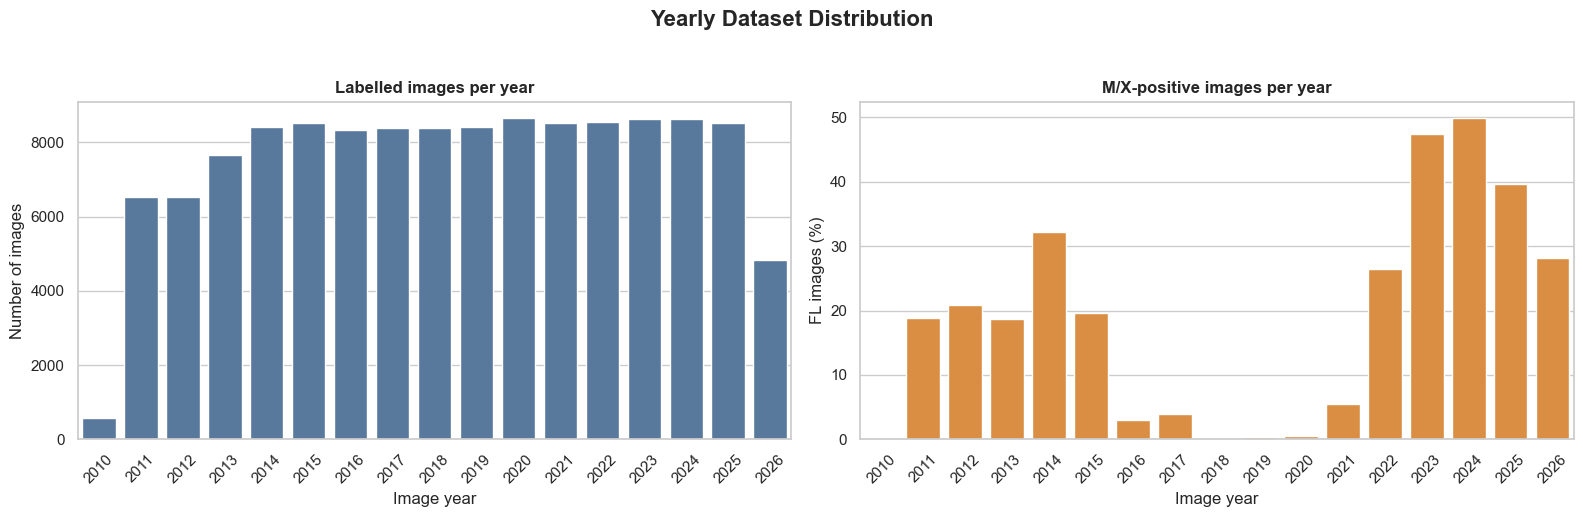

In [5]:
# Separate views are used because FL counts are much smaller than NF counts.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=yearly, x="year", y="total", color="#4C78A8", ax=axes[0])
axes[0].set_title("Labelled images per year", fontweight="bold")
axes[0].set_xlabel("Image year")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=yearly, x="year", y="FL_percent", color="#F28E2B", ax=axes[1])
axes[1].set_title("M/X-positive images per year", fontweight="bold")
axes[1].set_xlabel("Image year")
axes[1].set_ylabel("FL images (%)")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Yearly Dataset Distribution", fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 4. Criteria for selecting four continual-learning stages

All candidate stages are chronological, cover 2010-2022 exactly once, and contain at least two calendar years. Two complementary measures are used:

1. **Size variation:** variation in the total number of images across the four stages.
2. **Imbalance variation:** variation in the NF:FL ratio across the four stages.

Both are coefficients of variation: `standard deviation / mean`. A value of zero means perfect equality; lower values are better.

> A low value for only one measure is insufficient. A stage can have a convenient size but almost no FL samples, or a convenient class ratio but many more training updates than the other stages.

In [6]:
def summarize_period(data, name, start_year, end_year):
    """Return size and binary-class statistics for one inclusive period."""
    period_data = data[data["year"].between(start_year, end_year)]
    total = len(period_data)
    fl = int(period_data["target"].sum())
    nf = total - fl

    return {
        "period": name, "years": f"{start_year}-{end_year}",
        "total": total, "FL": fl, "NF": nf,
        "FL_percent": 100 * fl / total if total else np.nan,
        "NF_to_FL": nf / fl if fl else np.nan,
    }


def evaluate_periods(periods):
    """Calculate the two variation measures for four stages."""
    details = [
        summarize_period(df, f"Stage {number}", start, end)
        for number, (start, end) in enumerate(periods, start=1)
    ]
    totals = np.array([stage["total"] for stage in details], dtype=float)
    ratios = np.array([stage["NF_to_FL"] for stage in details], dtype=float)
    return details, totals.std() / totals.mean(), ratios.std() / ratios.mean()


# Test every valid combination of three year boundaries.
candidate_rows = []
for cut1, cut2, cut3 in combinations(range(2010, 2022), 3):
    periods = [(2010, cut1), (cut1 + 1, cut2),
               (cut2 + 1, cut3), (cut3 + 1, 2022)]
    if any(end - start + 1 < 2 for start, end in periods):
        continue

    _, size_variation, imbalance_variation = evaluate_periods(periods)
    candidate_rows.append({
        "periods": periods,
        "size_variation": size_variation,
        "imbalance_variation": imbalance_variation,
        "combined_score": size_variation + imbalance_variation,
    })

candidates = pd.DataFrame(candidate_rows)
print(f"Candidate partitions evaluated: {len(candidates)}")

Candidate partitions evaluated: 56


## 5. Compare four representative partitions

The comparison includes the professor's initial proposal, the lowest combined score, the lowest imbalance variation, and the lowest size variation.

In [8]:
def build_strategy(name, periods):
    """Package stage details and comparison measures."""
    details, size_variation, imbalance_variation = evaluate_periods(periods)
    return {
        "strategy": name, "periods": periods,
        "boundaries": " | ".join(f"{start}-{end}" for start, end in periods),
        "size_variation": size_variation,
        "imbalance_variation": imbalance_variation,
        "combined_score": size_variation + imbalance_variation,
        "details": details,
    }

proposed_periods = [(2010, 2014), (2015, 2018),
                    (2019, 2020), (2021, 2022)]

strategies = [
    build_strategy("Dicussed with Dr. Pandey", proposed_periods),
    build_strategy("Lowest combined",
                   candidates.nsmallest(1, "combined_score").iloc[0]["periods"]),
    build_strategy("Lowest imbalance variation",
                   candidates.nsmallest(1, "imbalance_variation").iloc[0]["periods"]),
    build_strategy("Lowest size variation",
                   candidates.nsmallest(1, "size_variation").iloc[0]["periods"]),
]

comparison = pd.DataFrame([{
    "Strategy": item["strategy"],
    "Stage boundaries": item["boundaries"],
    "Size variation": item["size_variation"],
    "Imbalance variation": item["imbalance_variation"],
    "Combined score": item["combined_score"],
} for item in strategies])

display(
    comparison.style
    .format({"Size variation": "{:.3f}",
             "Imbalance variation": "{:.3f}",
             "Combined score": "{:.3f}"})
    .set_caption("Comparison of representative chronological partitions")
)

,Strategy,Stage boundaries,Size variation,Imbalance variation,Combined score
0,Dicussed with Dr. Pandey,2010-2014 | 2015-2018 | 2019-2020 | 2021-2022,0.304,1.531,1.836
1,Lowest combined,2010-2012 | 2013-2014 | 2015-2018 | 2019-2022,0.393,0.575,0.968
2,Lowest imbalance variation,2010-2011 | 2012-2013 | 2014-2019 | 2020-2022,0.676,0.333,1.009
3,Lowest size variation,2010-2013 | 2014-2016 | 2017-2019 | 2020-2022,0.074,1.283,1.357


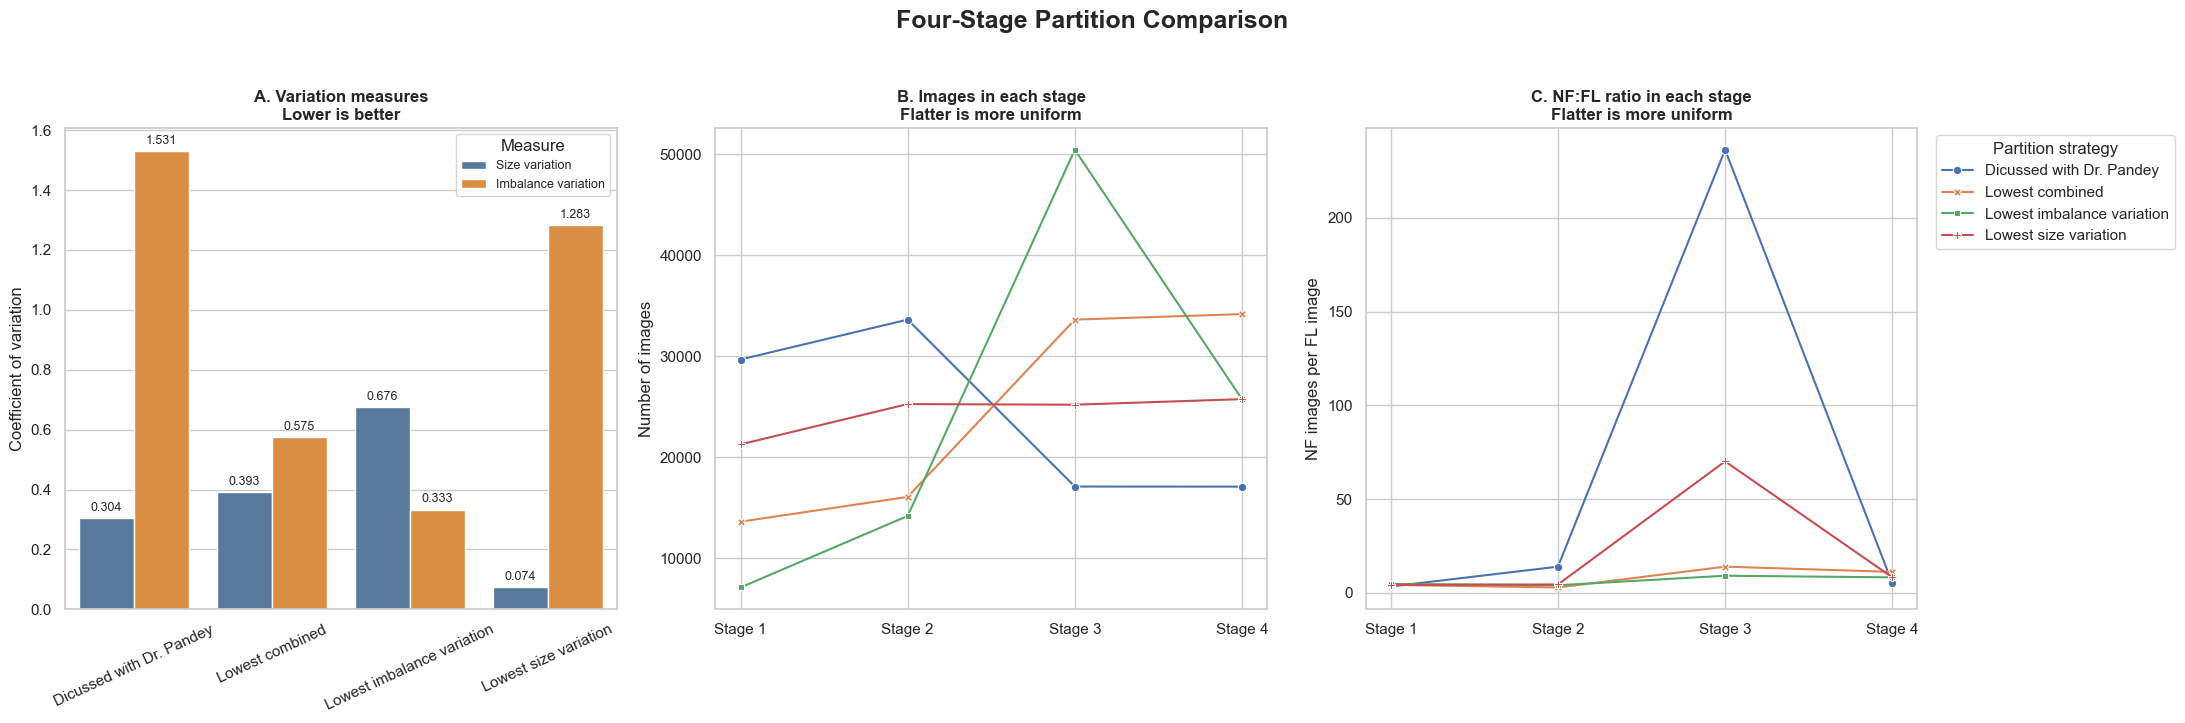

In [9]:
# Create one stage-level table for the presentation charts.
stage_rows = []
for strategy in strategies:
    for detail in strategy["details"]:
        stage_rows.append({"Strategy": strategy["strategy"], **detail})
stage_table = pd.DataFrame(stage_rows)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

variation_long = comparison.melt(
    id_vars="Strategy",
    value_vars=["Size variation", "Imbalance variation"],
    var_name="Measure", value_name="Variation",
)
sns.barplot(data=variation_long, x="Strategy", y="Variation",
            hue="Measure", palette=["#4C78A8", "#F28E2B"], ax=axes[0])
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
axes[0].set_title("A. Variation measures\nLower is better", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Coefficient of variation")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Measure", fontsize=9)

sns.lineplot(data=stage_table, x="period", y="total", hue="Strategy",
             style="Strategy", markers=True, dashes=False, ax=axes[1])
axes[1].set_title("B. Images in each stage\nFlatter is more uniform", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of images")
axes[1].legend_.remove()

sns.lineplot(data=stage_table, x="period", y="NF_to_FL", hue="Strategy",
             style="Strategy", markers=True, dashes=False, ax=axes[2])
axes[2].set_title("C. NF:FL ratio in each stage\nFlatter is more uniform", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("NF images per FL image")
axes[2].legend(title="Partition strategy", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Four-Stage Partition Comparison", fontsize=18, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 6. Why three alternatives are not selected

### Professor's initial proposal: 2010-2014 | 2015-2018 | 2019-2020 | 2021-2022

- Stage 3 contains only **72 FL images** and **17,016 NF images**.
- Its ratio is approximately **1 FL : 236 NF**.
- Training and Fisher estimation would be dominated by negative samples.

### Lowest size variation: 2010-2013 | 2014-2016 | 2017-2019 | 2020-2022

- Stage sizes are very similar.
- Stage 3 contains only **354 FL images** with a ratio of approximately **1:70**.
- Equal size does not compensate for an almost flare-free stage.

### Lowest imbalance variation: 2010-2011 | 2012-2013 | 2014-2019 | 2020-2022

- Its natural class ratios are the most similar among the candidates.
- Stage sizes range from **7,090** to **50,444** images.
- Stage 3 spans six years and is more than seven times the size of Stage 1.
- Epoch-based training would give Stage 3 far more updates and could dominate the sequence.

## 7. Recommended partition

The **lowest combined-score split** is selected as the most defensible compromise:

1. **Stage 1:** 2010-2012
2. **Stage 2:** 2013-2014
3. **Stage 3:** 2015-2018
4. **Stage 4:** 2019-2022
5. **Validation:** 2023-2024
6. **Test:** 2025-July 2026

Reasons:

- Every training stage contains more than 2,200 positive FL images.
- It avoids the nearly flare-free stage produced by the proposed and lowest-size splits.
- It avoids the extreme 7,090-versus-50,444 size difference produced by the lowest-imbalance split.
- It preserves chronological order and meaningful solar-cycle distribution changes.
- It is a compromise, not a perfectly balanced partition. Remaining imbalance should be handled during training.

In [10]:
# Final recommended training-stage statistics.
recommended = next(item for item in strategies if item["strategy"] == "Lowest combined")
recommended_table = pd.DataFrame(recommended["details"])

display(
    recommended_table.style
    .format({"total": "{:,}", "FL": "{:,}", "NF": "{:,}",
             "FL_percent": "{:.2f}%", "NF_to_FL": "{:.2f}"})
    .set_caption("Recommended four-stage training partition")
)

future_table = pd.DataFrame([
    summarize_period(df, "Validation", 2023, 2024),
    summarize_period(df, "Test", 2025, 2026),
])
display(
    future_table.style
    .format({"total": "{:,}", "FL": "{:,}", "NF": "{:,}",
             "FL_percent": "{:.2f}%", "NF_to_FL": "{:.2f}"})
    .set_caption("Fixed future validation and test periods")
)

,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Stage 1,2010-2012,"13,606","2,593","11,013",19.06%,4.25
1,Stage 2,2013-2014,"16,061","4,138","11,923",25.76%,2.88
2,Stage 3,2015-2018,"33,618","2,244","31,374",6.67%,13.98
3,Stage 4,2019-2022,"34,164","2,801","31,363",8.20%,11.20


,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Validation,2023-2024,"17,279","8,408","8,871",48.66%,1.06
1,Test,2025-2026,"13,365","4,745","8,620",35.50%,1.82


## 8. Implications for the EWC experiment

- Keep the complete natural label files as the source of truth.
- Use class-weighted loss or a weighted sampler instead of permanently deleting most negative data.
- Use a comparable number of optimization steps for every stage so large stages do not automatically receive much more training.
- Estimate the EWC Fisher information from a fixed-size, class-controlled sample after each stage.
- Keep validation and final test sets at their natural class distributions.
- Add a small chronological evaluation holdout for every training stage. Evaluate all earlier holdouts after each new stage to measure catastrophic forgetting.
- Avoid random splits of neighboring hourly images. Their 24-hour target windows overlap, so chronological holdouts should use at least a 24-hour separation from training data.

## Final conclusion

For the current experiment, **2010-2012 | 2013-2014 | 2015-2018 | 2019-2022** is the best of the four examined partitions. It provides the strongest compromise between stage size, positive-sample availability, class imbalance, and chronological meaning.